<a href="https://colab.research.google.com/github/AGarcia04/InteligenciaComputacional/blob/main/ICO_EDA_y_PreprocesamientoT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset seleccionado**

***PGA Tour Golf Data (2015 - 2022)***

Fuente: Kaggle https://www.kaggle.com/datasets/robikscube/pga-tour-golf-data-20152022

El dataset contiene estadísticas a nivel torneo y jugador, incluyendo resultados finales, scores, rondas, métricas de desempeño y posición final.

Tipo de problema: Clasificación binaria

**Objetivo**

El objetivo de este problema es construir un modelo de clasificación que, usando estadísticas de desempeño de jugadores en el PGA Tour, permita predecir si un jugador tiene probabilidad alta de ganar un torneo.





In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/ASA-All-PGA-Raw-Data-Tourn-Level.csv")
df.shape
df.head()

,Player_initial_last,tournament id,player id,hole_par,strokes,hole_DKP,hole_FDP,hole_SDP,streak_DKP,streak_FDP,...,purse,season,no_cut,Finish,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,sg_total
0,A. Ancer,401353224,9261,288,289,60.0,51.1,56,3,7.6,...,12.0,2022,0,T32,0.20,-0.13,-0.08,0.86,0.65,0.85
1,A. Hadwin,401353224,5548,288,286,72.5,61.5,61,8,13.0,...,12.0,2022,0,T18,0.36,0.75,0.31,0.18,1.24,1.60
2,A. Lahiri,401353224,4989,144,147,21.5,17.4,27,0,0.0,...,12.0,2022,0,CUT,-0.56,0.74,-1.09,0.37,0.02,-0.54
3,A. Long,401353224,6015,144,151,20.5,13.6,17,0,0.4,...,12.0,2022,0,CUT,-1.46,-1.86,-0.02,0.80,-1.08,-2.54
4,A. Noren,401353224,3832,144,148,23.5,18.1,23,0,1.2,...,12.0,2022,0,CUT,0.53,-0.36,-1.39,0.19,-1.56,-1.04


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36864 entries, 0 to 36863
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Player_initial_last  36864 non-null  object 
 1   tournament id        36864 non-null  int64  
 2   player id            36864 non-null  int64  
 3   hole_par             36864 non-null  int64  
 4   strokes              36864 non-null  int64  
 5   hole_DKP             36864 non-null  float64
 6   hole_FDP             36864 non-null  float64
 7   hole_SDP             36864 non-null  int64  
 8   streak_DKP           36864 non-null  int64  
 9   streak_FDP           36864 non-null  float64
 10  streak_SDP           36864 non-null  int64  
 11  n_rounds             36864 non-null  int64  
 12  made_cut             36864 non-null  int64  
 13  pos                  21317 non-null  float64
 14  finish_DKP           36864 non-null  int64  
 15  finish_FDP           36864 non-null 

In [4]:
# Crear la variable objetivo:
# winner = 1 si el jugador terminó en posición 1
# winner = 0 en cualquier otro caso
finish_str = df["Finish"].astype(str).str.strip()
df["winner"] = finish_str.isin(["1", "T1"]).astype(int)

# Revisar la distribución del target
df["winner"].value_counts()
df["winner"].value_counts(normalize=True)

,proportion
winner,
0,0.993435
1,0.006565


In [5]:

num_cols = [
    "strokes",
    "hole_par",
    "n_rounds",
    "made_cut",
    "total_DKP",
    "total_FDP",
    "total_SDP",
    "sg_putt",
    "sg_arg",
    "sg_app",
    "sg_ott",
    "sg_t2g",
    "sg_total"]

In [6]:
cat_cols = [
    "tournament name",
    "course",
    "season"]

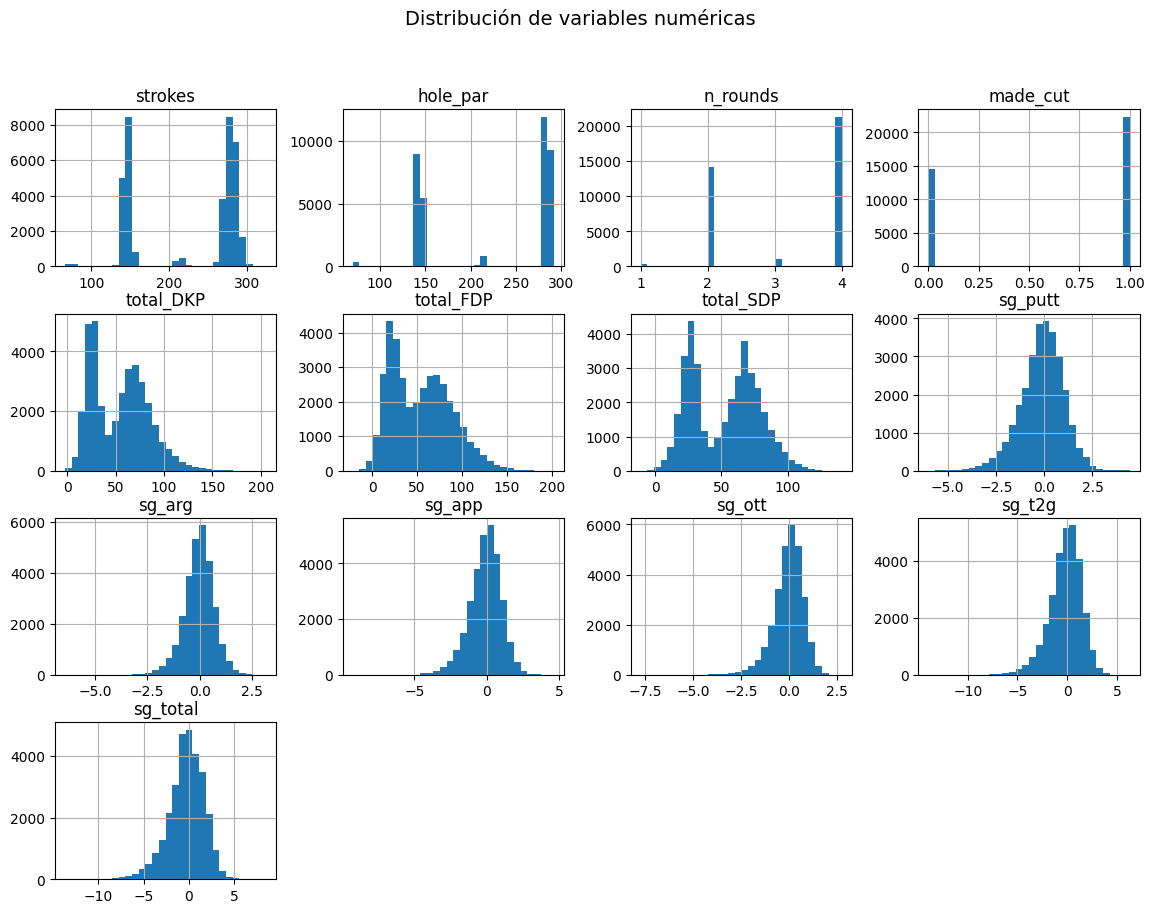

In [7]:
df[num_cols].hist(bins=30, figsize=(14,10))
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.show()

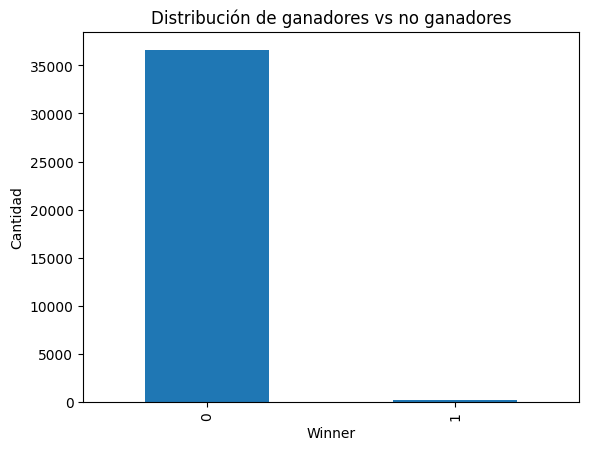

In [8]:
df["winner"].value_counts().plot(kind="bar")
plt.title("Distribución de ganadores vs no ganadores")
plt.xlabel("Winner")
plt.ylabel("Cantidad")
plt.show()

In [9]:
nulls = df[num_cols + cat_cols].isna().mean().sort_values(ascending=False)
nulls

,0
sg_putt,0.208442
sg_ott,0.208442
sg_app,0.208442
sg_arg,0.208442
sg_t2g,0.208442
sg_total,0.208415
n_rounds,0.000000
strokes,0.000000
total_SDP,0.000000
total_FDP,0.000000


El análisis exploratorio muestra que el conjunto de datos presenta un fuerte desbalance en la variable objetivo. Las métricas de Strokes Gained exhiben mayor variabilidad y parecen ser altamente informativas para el desempeño del jugador. Se identificaron valores nulos en métricas avanzadas, lo cual justifica el uso de imputación. Las variables categóricas como torneo y campo aportan contexto relevante para la predicción.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [11]:
from sklearn.model_selection import train_test_split

X = df[num_cols + cat_cols]
y = df["winner"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

En las variables numéricas se utilizó imputación mediante la mediana, ya que el conjunto de datos presenta valores faltantes principalmente en métricas avanzadas de desempeño (strokes gained). Posteriormente, se aplicó un escalado estándar para asegurar que todas las variables numéricas se encuentren en una escala comparable. En el caso de las variables categóricas, se utilizó imputación con el valor más frecuente para manejar posibles valores faltantes sin eliminar observaciones, seguida de One-Hot Encoding para convertir las categorías en representaciones numéricas compatibles con el modelo.

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

y_pred[:100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])